In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from itertools import combinations

In [ ]:
# Define file paths
input_path = '../data/processed/BRFSS_Diabetes_Cleaned.csv'
output_path = "../data/processed/BRFSS_Diabetes_Relevant_Features.csv"

# Load the fully imputed dataset
import pandas as pd

try:
    df = pd.read_csv(input_path)
    print(f"Successfully loaded cleaned dataset from: {input_path}")
except FileNotFoundError:
    raise FileNotFoundError(f"Cleaned dataset not found. Please ensure '{input_path}' exists.")

# --- Define Target and Selected Features ---
target = "has_diabetes"

# Best 17 user-friendly, statistically significant features for diabetes prediction
selected_features = [
    # Demographics & Socioeconomics
    'age_cat',
    'low_income',
    'college_graduate',
    
    # Anthropometrics & Clinical History (self-reported)
    'BMI',
    'has_high_bp',
    'had_cvd',
    
    # Lifestyle & Behavior
     'ever_smoked_100',
    'is_binge_drinker',
   
    'total_fv_servings', ##
    'alcohol_days_year',
    
    # Health Status & Comorbidities
    'has_kidney_disease',
    'has_arthritis',
    'has_depression',
    'general_health_risk',    
    'chronic_conditions_standard',
    'physical_health_bad',
    
    # Other Relevant Factors
   
    'lives_alone',
]


# --- Validation and Final DataFrame Creation ---
available_features = [col for col in selected_features if col in df.columns]
missing_features = [col for col in selected_features if col not in df.columns]

if missing_features:
    print(f"Warning: The following features are not in the dataset and will be skipped: {missing_features}")
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset. Please verify the target name.")
if not available_features:
    raise ValueError("No selected features are available in the dataset.")

# Create final dataframe
df_selected = df[available_features + [target]].copy()

# Optional: Drop rows with any missing values in these key features (if minimal)
# df_selected = df_selected.dropna(subset=available_features + [target])

# Print summary
print(f"\nFeature Selection Summary:")
print(f"Selected {len(available_features)} features + target '{target}'.")
print(f"Final dataset shape: {df_selected.shape}")
if missing_features:
    print(f"Skipped features: {missing_features}")

# Save the reduced dataset
df_selected.to_csv(output_path, index=False)
print(f"\nSuccessfully saved the feature-selected dataset to: {output_path}")

Successfully loaded cleaned dataset from: ../data/processed/BRFSS_Diabetes_Cleaned.csv

Feature Selection Summary:
Selected 17 features + target 'has_diabetes'.
Final dataset shape: (364124, 18)

Successfully saved the feature-selected dataset to: ../data/processed/BRFSS_Diabetes_Relevant_Features.csv


Successfully loaded feature-selected dataset from: ../data/processed/BRFSS_Diabetes_Relevant_Features.csv
Dataset shape after encoding: (364124, 23). All features are now numerical.

--- Generating Feature Distribution Visualizations ---


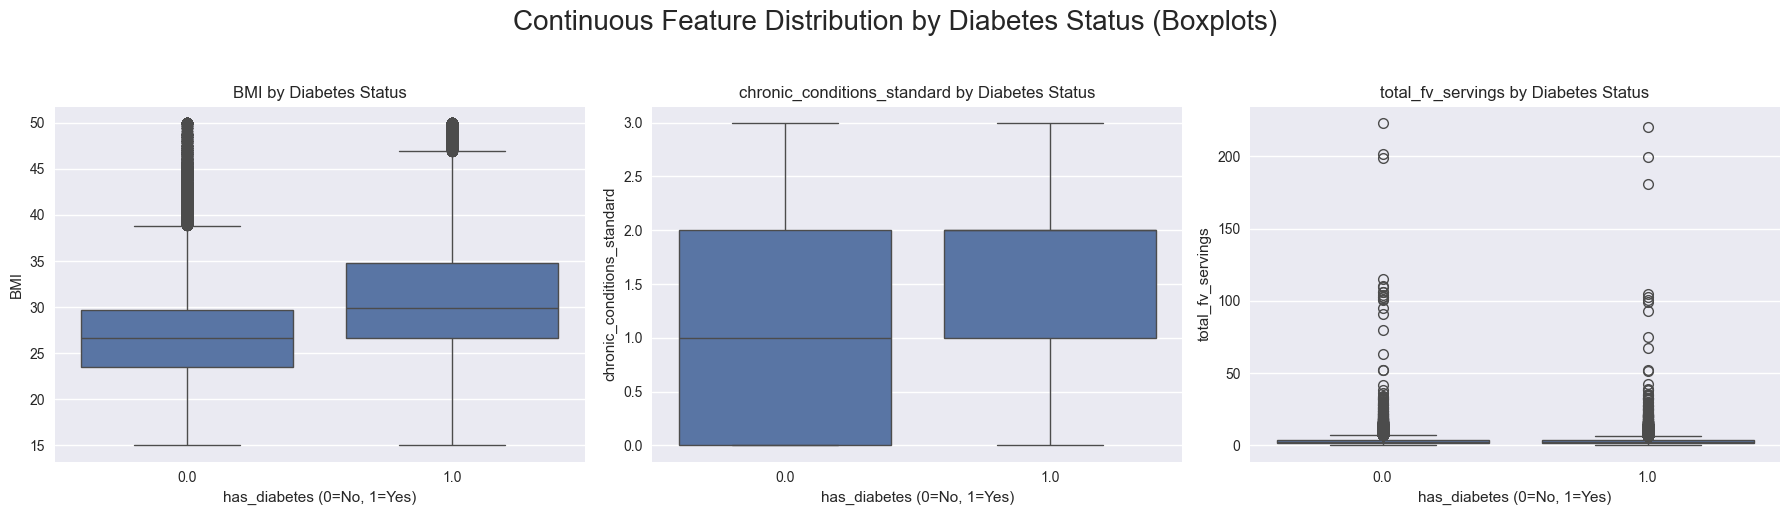

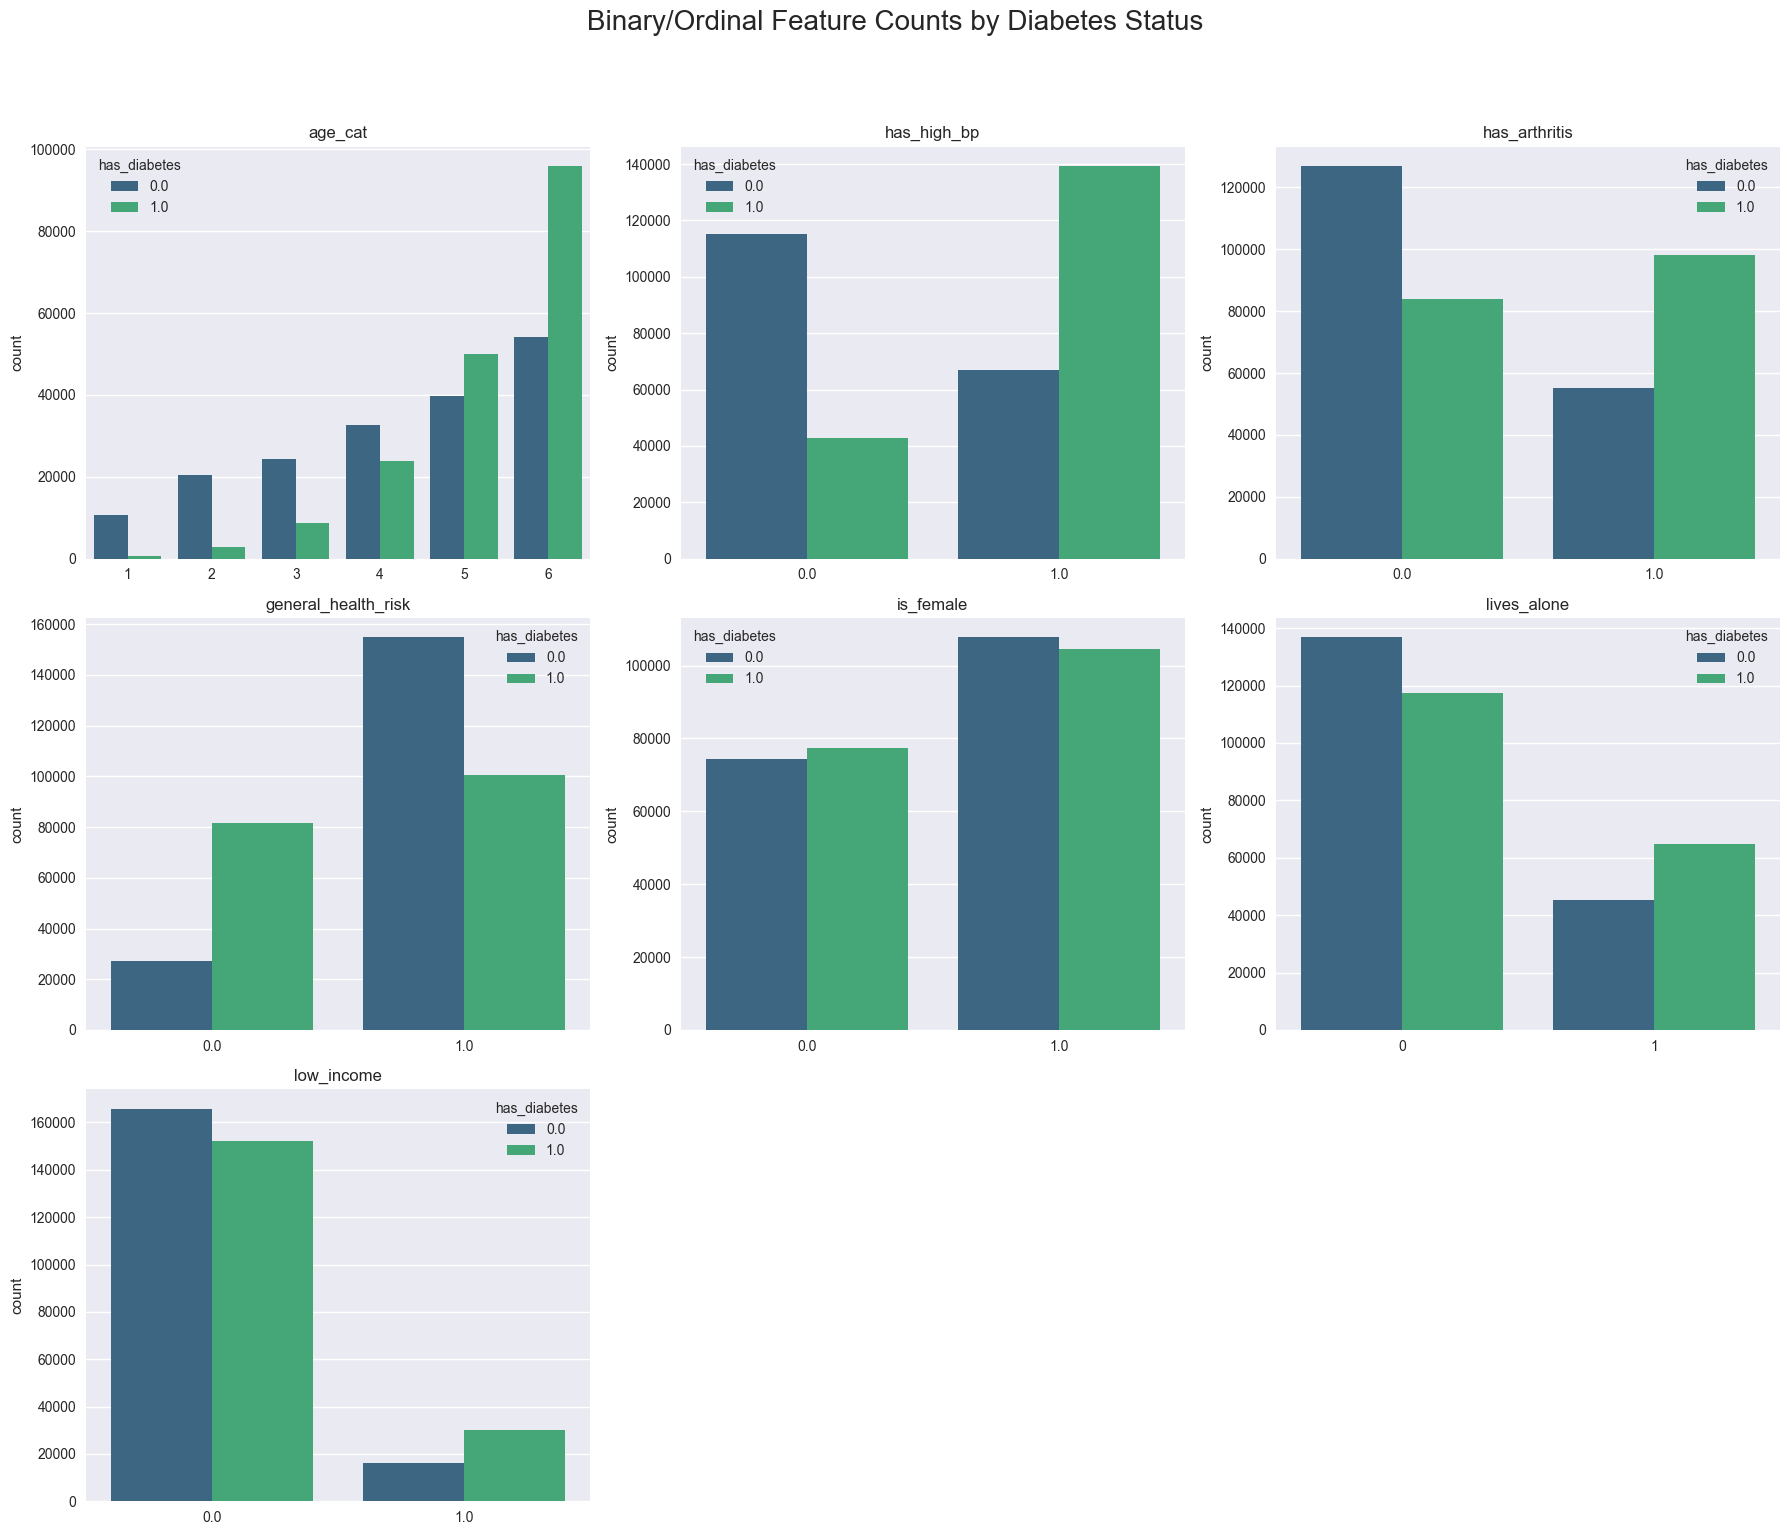

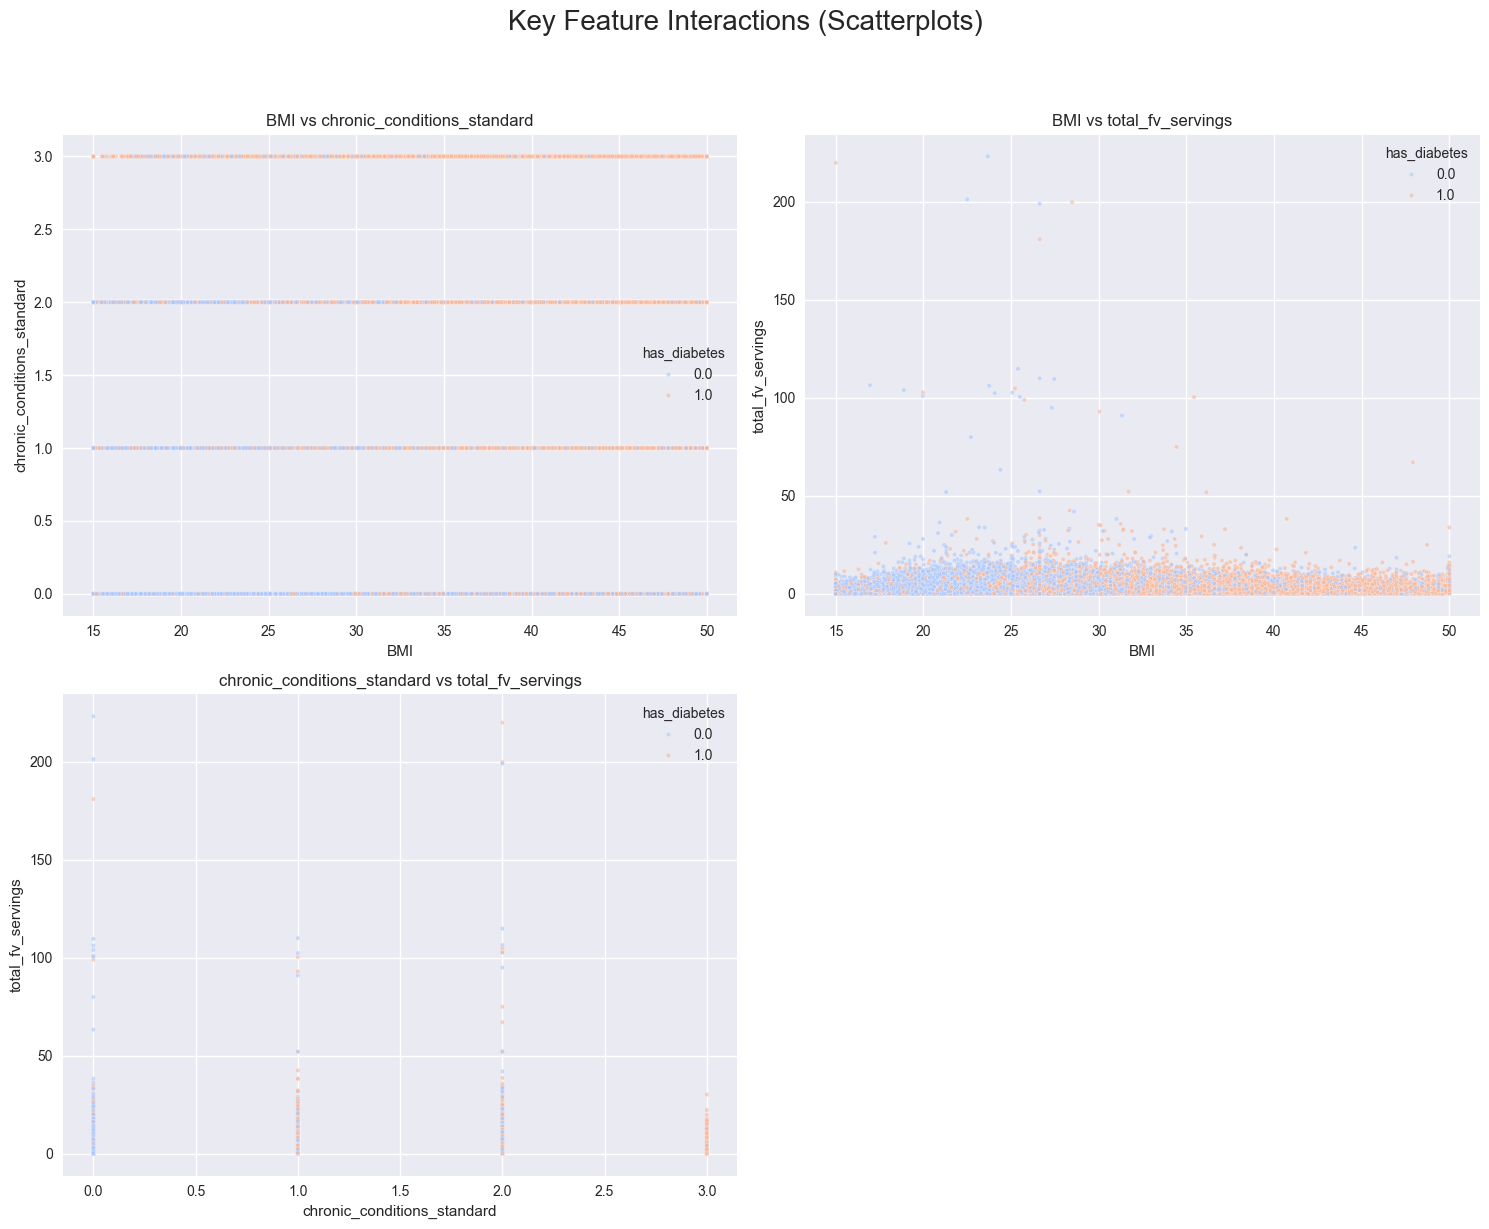

In [ ]:
# Set plot style for better aesthetics
plt.style.use('seaborn-v0_8')

# --- 1. Load Data and Define Target ---
input_path = '../data/processed/BRFSS_Diabetes_Relevant_Features.csv'
target = "has_diabetes"

try:
    df = pd.read_csv(input_path)
    print(f"Successfully loaded feature-selected dataset from: {input_path}")
except FileNotFoundError:
    raise FileNotFoundError(f"File not found. Please ensure '{input_path}' exists after running the feature selection script.")

# Final Pre-processing: One-Hot Encoding (OHE)

# Identify the remaining categorical features (type 'object')
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    print(f"Applying One-Hot Encoding to categorical features: {categorical_cols}")
    # Convert categorical variables into dummy/indicator variables (OHE)
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
else:
    df_encoded = df.copy()

print(f"Dataset shape after encoding: {df_encoded.shape}. All features are now numerical.")

# Identify Feature Subsets for Focused Visualization

# Core continuous features for boxplots/scatterplots
continuous_features = [
    'BMI', 'chronic_conditions_standard', 'cholesterol_screening_score', 
    'care_access_score', 'join_pain_level', 'total_activity_duration', 
    'total_fv_servings'
]
continuous_features = [col for col in continuous_features if col in df_encoded.columns] # Ensure existence

# Core binary/ordinal features for countplots
binary_categorical_cols = [
    'age_cat', 'high_bp_risk', 'has_high_bp', 'had_cvd', 
    'has_arthritis', 'general_health_risk', 'is_female', 'lives_alone', 
    'low_income', 
    'blood_sugar_checks_missing_indicator' # Keep the MNAR indicator here
]
binary_categorical_cols = [col for col in binary_categorical_cols if col in df_encoded.columns] # Ensure existence


# VISUALIZATIONS
print("\n--- Generating Feature Distribution Visualizations ---")

# Boxplots for Continuous/Numerical Features
if continuous_features:
    n_cols = 3
    n_rows = (len(continuous_features) + n_cols - 1) // n_cols
    plt.figure(figsize=(18, 5 * n_rows))
    plt.suptitle('Continuous Feature Distribution by Diabetes Status (Boxplots)', fontsize=20, y=1.02)
    
    for i, col in enumerate(continuous_features, 1):
        plt.subplot(n_rows, n_cols, i)
        # Compare distribution of each feature between diabetic (1) and non-diabetic (0) groups
        sns.boxplot(data=df_encoded, x=target, y=col)
        plt.title(f'{col} by Diabetes Status')
        plt.xlabel('has_diabetes (0=No, 1=Yes)')
        plt.ylabel(col)
    
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# Countplots for Binary and Categorical Features
if binary_categorical_cols:
    n_cols = 3
    n_rows = (len(binary_categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    plt.suptitle('Binary/Ordinal Feature Counts by Diabetes Status', fontsize=20, y=1.02)
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for idx, col in enumerate(binary_categorical_cols):
        sns.countplot(data=df_encoded, x=col, hue=target, ax=axes[idx], palette='viridis')
        axes[idx].set_title(f'{col}')
        axes[idx].set_xlabel('')
        axes[idx].legend(title='has_diabetes')
    
    for j in range(len(binary_categorical_cols), len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# Scatterplots (Interactions between key continuous features)
# We use itertools.combinations to select pairs automatically
feature_pairs = list(combinations(continuous_features, 2))[:4] # Limiting to 4 key pairs

if feature_pairs:
    n_cols = 2
    n_rows = (len(feature_pairs) + n_cols - 1) // n_cols
    plt.figure(figsize=(15, 6 * n_rows))
    plt.suptitle('Key Feature Interactions (Scatterplots)', fontsize=20, y=1.02)
    
    for i, (x, y) in enumerate(feature_pairs, 1):
        plt.subplot(n_rows, n_cols, i)
        # Use hue to show the separation between classes
        sns.scatterplot(data=df_encoded, x=x, y=y, hue=target, alpha=0.6, palette='coolwarm', s=10)
        plt.title(f'{x} vs {y}')
        plt.legend(title='has_diabetes')
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


In [4]:

# Load the cleaned dataset
input_path = '../data/processed/BRFSS_Diabetes_Relevant_Features.csv'
df = pd.read_csv(input_path)
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Define target and features
target = 'has_diabetes'
features = [col for col in df.columns if col != target]

# Split features and target
X = df[features]
y = df[target]

# Perform train-test split (80-20 split, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Combine features and target back into DataFrames
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Create output directory
output_dir = '../data/train-test/'
os.makedirs(output_dir, exist_ok=True)

# Save preprocessed train and test sets
train_df.to_csv(os.path.join(output_dir, 'train_set.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test_set.csv'), index=False)

# Print diagnostics
print(f"\nTrain set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTrain and test sets saved to:")
print(f"   {os.path.join(output_dir, 'train_set.csv')}")
print(f"   {os.path.join(output_dir, 'test_set.csv')}")



Loaded dataset: 364,124 rows, 18 columns

Train set shape: (291299, 18)
Test set shape: (72825, 18)

Train class distribution:
has_diabetes
1.0    50.00%
0.0    50.00%
Name: proportion, dtype: object

Test class distribution:
has_diabetes
0.0    50.00%
1.0    50.00%
Name: proportion, dtype: object

Train and test sets saved to:
   ../data/train-test/train_set.csv
   ../data/train-test/test_set.csv


## Total Time = 27.8S